# Step 1 — Cell Composition Predicts COVID-19 Severity

**Question:** Do the *fractions* of different nasal cell types in a patient's swab predict whether they had mild or severe COVID-19?

**Approach:**
1. For each COVID+ patient, count how many cells of each Coarse_Annotation type they have.
2. Convert to fractions (rows sum to 1).
3. Define a binary severity label from WHO_Score_at_Peak.
4. Train a Random Forest with cross-validation; report AUC and feature importance.

**Note on splits:** Each patient is one row, so a standard StratifiedKFold *is* a patient-level split.


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")

## 1. Load patient metadata

This is the per-patient clinical table (`Walsh2025_Supplementary_Table1_Pt_Metadata.csv`).
Each row = one patient.

In [37]:
PATIENT_META_PATH = r"C:\Users\marya\Downloads\Step 1 - Cell Composition\Walsh2025_Supplementary_Table1_Pt_Metadata.csv"
pt = pd.read_csv(PATIENT_META_PATH)
pt.columns = pt.columns.str.strip()  # the CSV has 'Participant ' with a trailing space

print(f"Total patients: {len(pt)}")
print("\nGroup breakdown:")
print(pt["Variant_Vax_Group"].value_counts())
print("\nWHO score distribution (peak):")
print(pt["WHO_Score_at_Peak"].value_counts().sort_index())

Total patients: 112

Group breakdown:
Variant_Vax_Group
Ancestral        32
Control          26
Delta Unvax      19
Delta Vax        14
Omicron Vax      11
Omicron Unvax    10
Name: count, dtype: int64

WHO score distribution (peak):
WHO_Score_at_Peak
0    27
1     4
2     1
3     9
4    17
5    12
6     3
7     8
8    31
Name: count, dtype: int64


## 2. Load cell-level metadata

This is the per-cell table from the Single Cell Portal (the file with `NAME donor_id biosample_id ...`).
Each row = one cell. Note that SCP metadata files have a second row of TYPE annotations
(`group`, `numeric`, ...) which we have to skip.

In [38]:
CELL_META_PATH = r"C:\Users\marya\Downloads\Step 1 - Cell Composition\variant_vax_metadata.txt"

# skiprows=[1] drops the TYPE row directly under the header
cells = pd.read_csv(CELL_META_PATH, sep="\t", skiprows=[1])
cells = cells.rename(columns={"NAME": "cell_id"})

print(f"Total cells: {len(cells):,}")
print(f"Unique participants in cell table: {cells['donor_id'].nunique()}")
print("\nCoarse annotation counts:")
print(cells["Coarse_Annotation"].value_counts())

Total cells: 48,730
Unique participants in cell table: 112

Coarse annotation counts:
Coarse_Annotation
Ciliated               20683
Secretory               7356
MT-high                 5930
Squamous                3913
T_Cell                  2705
SARSCoV2-high           2551
Monocyte/Macrophage     2119
Basal                   1073
Goblet                   677
Ionocytes                574
Deuterosomal             565
Dendritic                416
B_Cell                   168
Name: count, dtype: int64


## 3. Filter to COVID-positive patients

We drop the 26 controls for the main severity question. Controls can be used later
as a sanity check (the model should easily separate them from COVID+).

In [39]:
covid_pt = pt[pt["Covid_Status"] == "positive"].copy()
covid_cells = cells[cells["donor_id"].isin(covid_pt["Participant"])].copy()

print(f"COVID+ patients: {len(covid_pt)}")
print(f"COVID+ cells: {len(covid_cells):,}")

COVID+ patients: 86
COVID+ cells: 38,989


## 4. Compute cells-per-patient × cell-type counts

This is the foundation of everything downstream. We also use it for sanity-checking
(do some patients have very few cells overall? Are some cell types extremely rare?).

In [41]:
counts = (
    covid_cells
    .groupby(["donor_id", "Coarse_Annotation"])
    .size()
    .unstack(fill_value=0)
    .astype(int)
)

cells_per_patient = counts.sum(axis=1)
print(f"Cells per patient — median: {cells_per_patient.median():.0f}, "
      f"min: {cells_per_patient.min()}, max: {cells_per_patient.max()}")
print(f"\nTotal cells per type:")
print(counts.sum(axis=0).sort_values(ascending=False))

Cells per patient — median: 330, min: 32, max: 1744

Total cells per type:
Coarse_Annotation
Ciliated               15180
Secretory               6656
MT-high                 4179
Squamous                3379
SARSCoV2-high           2503
T_Cell                  2181
Monocyte/Macrophage     2052
Basal                    751
Goblet                   572
Deuterosomal             554
Ionocytes                466
Dendritic                370
B_Cell                   146
dtype: int64


### Sanity-check plot: cell counts per patient × cell type

This is *exactly* the kind of figure to show in your slides early on. It tells you
(and your evaluators) whether the data is balanced enough for the analyses you're
about to do.

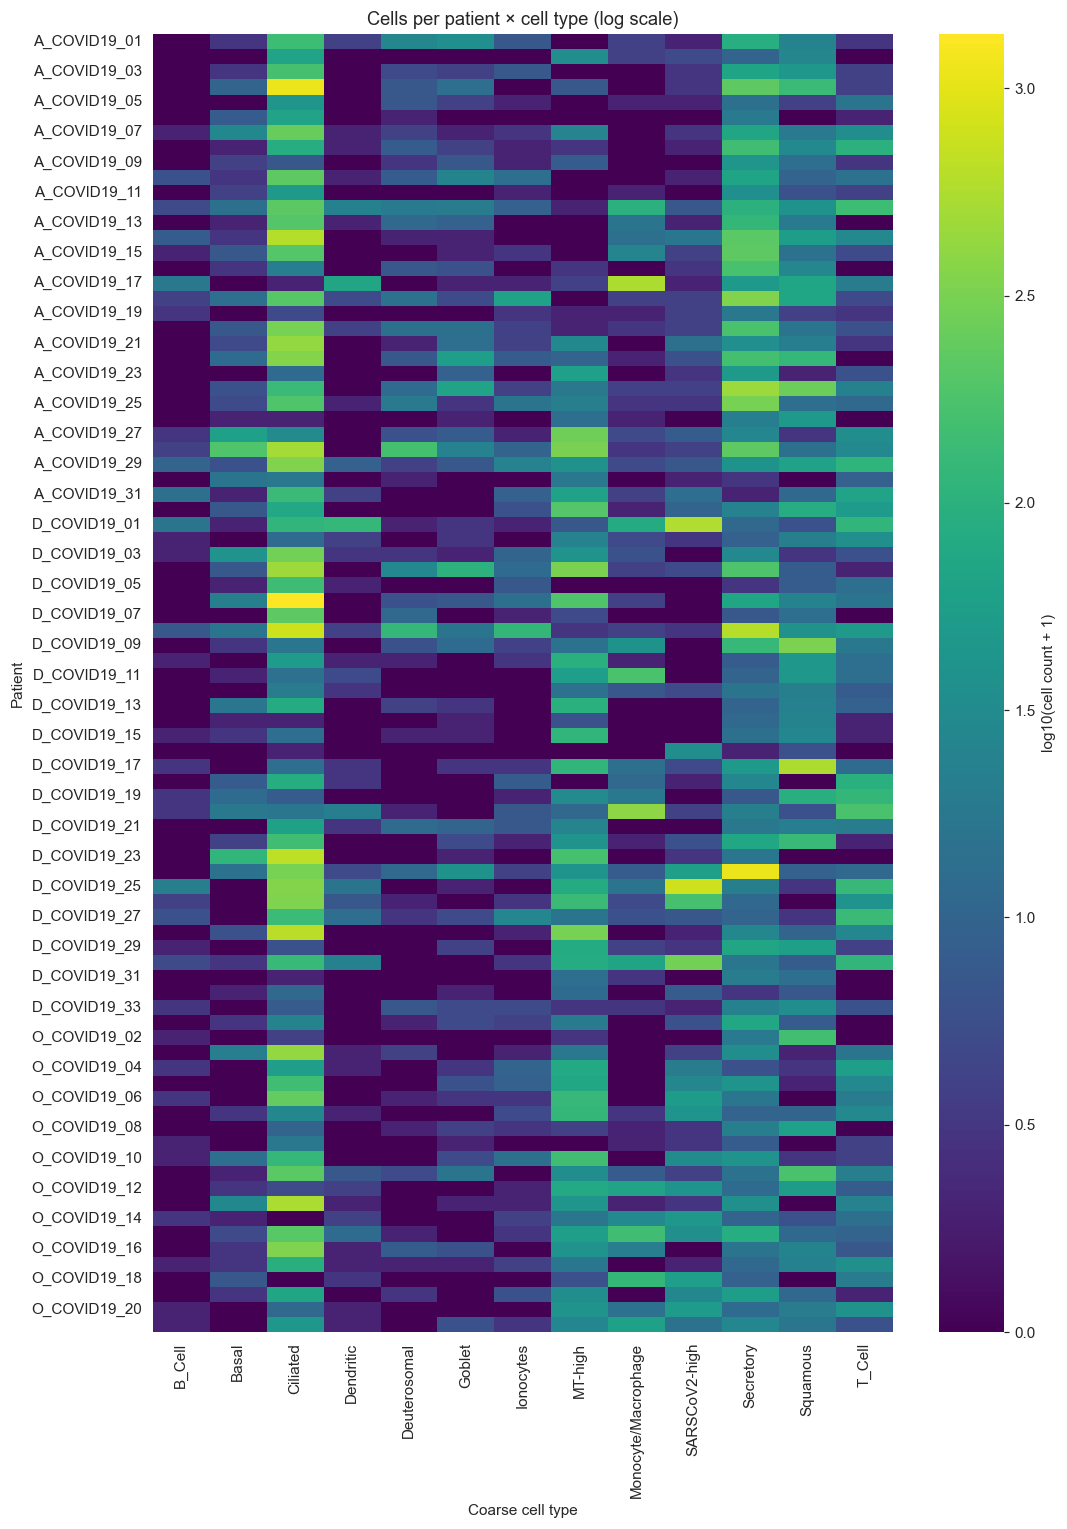

In [42]:
fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(
    np.log10(counts + 1),
    cmap="viridis",
    cbar_kws={"label": "log10(cell count + 1)"},
    ax=ax,
)
ax.set_title("Cells per patient × cell type (log scale)")
ax.set_xlabel("Coarse cell type")
ax.set_ylabel("Patient")
plt.tight_layout()
plt.show()

## 5. Convert to fractions

Each patient's row now sums to 1. Fractions are what the model actually sees —
raw counts would just be a proxy for "how many cells did we sequence from this patient."

In [43]:
fractions = counts.div(counts.sum(axis=1), axis=0)
print(fractions.head())
print(f"\nRow sums (should all be 1.0): {fractions.sum(axis=1).describe()}")

Coarse_Annotation  B_Cell     Basal  Ciliated  Dendritic  Deuterosomal  \
donor_id                                                                 
A_COVID19_01          0.0  0.006006  0.417417   0.009009      0.081081   
A_COVID19_02          0.0  0.000000  0.460432   0.000000      0.000000   
A_COVID19_03          0.0  0.006849  0.544521   0.000000      0.013699   
A_COVID19_04          0.0  0.006012  0.736139   0.000000      0.004008   
A_COVID19_05          0.0  0.000000  0.494118   0.000000      0.070588   

Coarse_Annotation    Goblet  Ionocytes   MT-high  Monocyte/Macrophage  \
donor_id                                                                
A_COVID19_01       0.102102   0.018018  0.000000             0.009009   
A_COVID19_02       0.000000   0.000000  0.230216             0.021583   
A_COVID19_03       0.010274   0.020548  0.000000             0.000000   
A_COVID19_04       0.008016   0.000000  0.004008             0.000000   
A_COVID19_05       0.035294   0.011765  0.0

In [44]:
fractions.to_csv("cell_type_fractions.csv", index=True)

## 6. Define the severity label

WHO_Score_at_Peak is bimodal in this cohort (lots of 0s and lots of 8s). We bin it
into a clean binary problem:

- **Not Severe** = WHO 1-4 
- **Severe** = WHO 5–8 
You can revisit this choice later (e.g., 3-class, or include moderate as severe)...

In [45]:
def binary_severity(who):
    return 1 if who >= 5 else 0  # severe vs not severe, no dropping


covid_pt["severity"] = covid_pt["WHO_Score_at_Peak"].apply(binary_severity)
labeled = covid_pt.dropna(subset=["severity"]).copy()
labeled["severity"] = labeled["severity"].astype(int)

#print(f"Patients after dropping moderate (WHO 3-4): {len(labeled)}")
print(labeled["severity"].value_counts().rename({0: "mild (WHO 0-2)", 1: "severe (WHO 5-8)"}))

severity
severe (WHO 5-8)    54
mild (WHO 0-2)      32
Name: count, dtype: int64


## 7. Build the ML-ready X, y

Inner-join keeps only patients who appear in BOTH the cell data and the labeled
clinical table.

In [48]:
data = fractions.merge(
    labeled[["Participant", "severity"]],
    left_index=True,
    right_on="Participant",
    how="inner",
).set_index("Participant")

X = data.drop(columns=["severity"])
y = data["severity"].values

print(f"X shape: {X.shape}")
print(f"y: mild={int((y == 0).sum())}, severe={int((y == 1).sum())}")
print(f"\nFeatures (cell-type fractions): {list(X.columns)}")

X shape: (86, 13)
y: mild=32, severe=54

Features (cell-type fractions): ['B_Cell', 'Basal', 'Ciliated', 'Dendritic', 'Deuterosomal', 'Goblet', 'Ionocytes', 'MT-high', 'Monocyte/Macrophage', 'SARSCoV2-high', 'Secretory', 'Squamous', 'T_Cell']


## 8. Train Random Forest with 5-fold cross-validation

We use `class_weight='balanced'` to handle any imbalance, and shallow trees
(`max_depth=5`) because n is small.

In [49]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_aucs = cross_val_score(rf, X, y, cv=cv, scoring="roc_auc")

print(f"5-fold CV AUC: {fold_aucs.mean():.3f} ± {fold_aucs.std():.3f}")
print(f"Per-fold: {np.round(fold_aucs, 3)}")

5-fold CV AUC: 0.717 ± 0.221
Per-fold: [0.87  0.803 0.318 0.652 0.943]


### Bootstrap confidence interval on the AUC

With ~50-70 patients, single fold AUCs are noisy. A bootstrap CI on the
pooled cross-validated predictions is more honest to report.

In [50]:
y_proba_cv = cross_val_predict(rf, X, y, cv=cv, method="predict_proba")[:, 1]

rng = np.random.default_rng(42)
n_boot = 1000
boot_aucs = []
for _ in range(n_boot):
    idx = rng.integers(0, len(y), len(y))
    if len(np.unique(y[idx])) < 2:
        continue
    boot_aucs.append(roc_auc_score(y[idx], y_proba_cv[idx]))
boot_aucs = np.array(boot_aucs)

print(f"Pooled CV AUC: {roc_auc_score(y, y_proba_cv):.3f}")
print(f"Bootstrap 95% CI: [{np.percentile(boot_aucs, 2.5):.3f}, {np.percentile(boot_aucs, 97.5):.3f}]")

Pooled CV AUC: 0.726
Bootstrap 95% CI: [0.586, 0.847]


### ROC curve

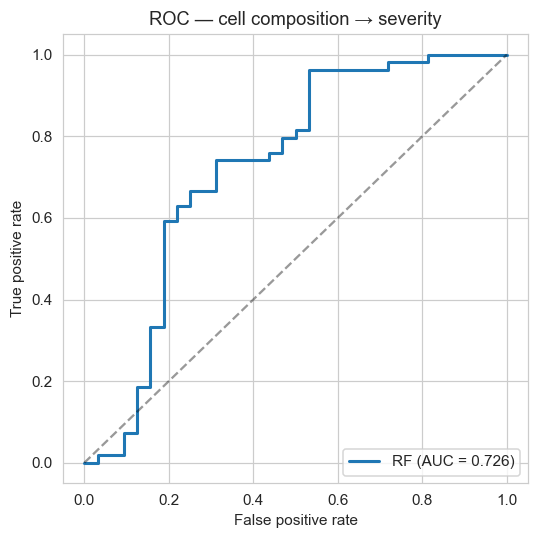

In [51]:
fpr, tpr, _ = roc_curve(y, y_proba_cv)
auc = roc_auc_score(y, y_proba_cv)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, lw=2, label=f"RF (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC — cell composition → severity")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 9. Feature importance — which cell types drive the prediction?

We fit on all data here (for visualization only — the AUC above is the honest number).

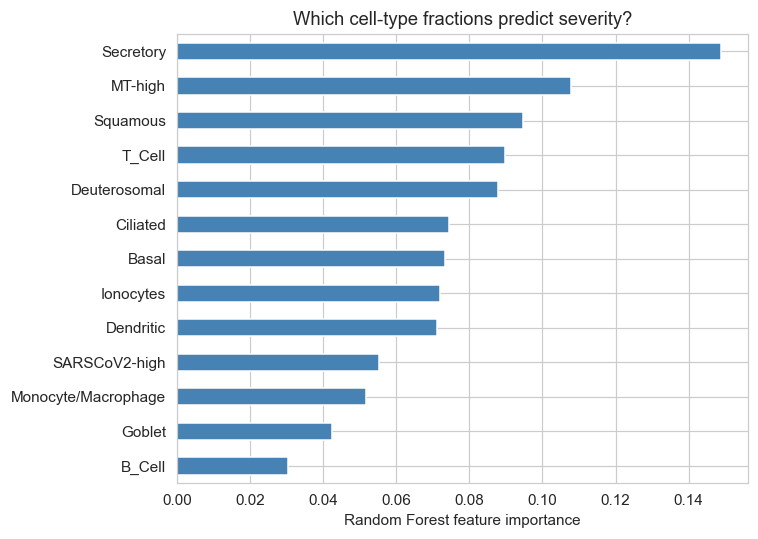

In [27]:
rf.fit(X, y)
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
importance.plot(kind="barh", color="steelblue", ax=ax)
ax.set_xlabel("Random Forest feature importance")
ax.set_title("Which cell-type fractions predict severity?")
plt.tight_layout()
plt.show()

In [28]:
from sklearn.inspection import permutation_importance
rf.fit(X, y)
perm = permutation_importance(rf, X, y, n_repeats=30, random_state=42, n_jobs=-1)
perm_df = pd.Series(perm.importances_mean, index=X.columns).sort_values()

## 10. Composition by severity group — the biology view

Feature importance tells you which cell types *matter*; this plot tells you *how* they matter
(enriched in severe? depleted? bimodal?).

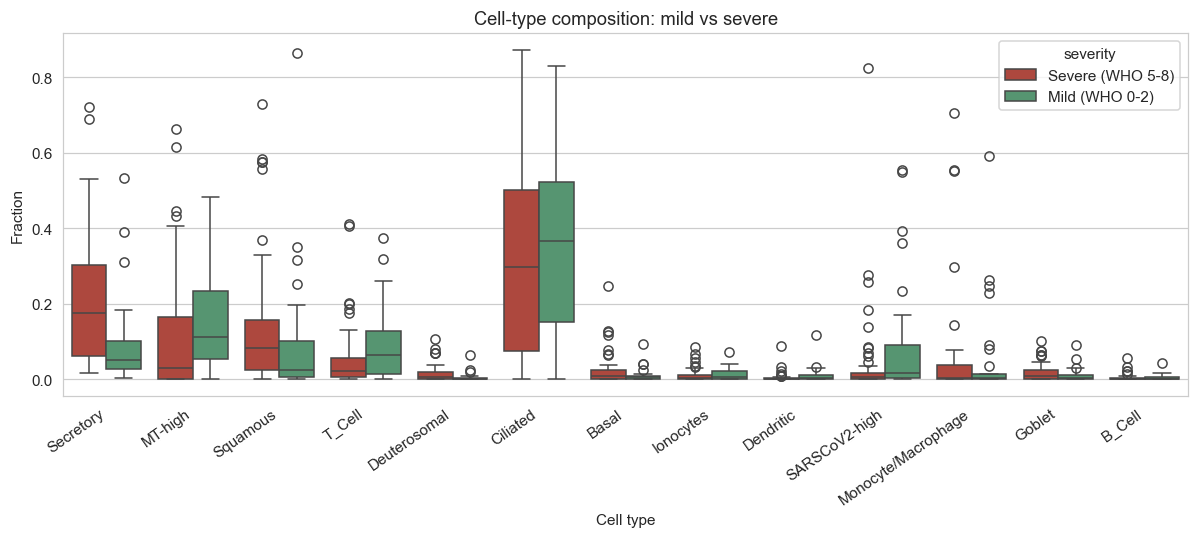

In [ ]:
plot_df = X.copy()
plot_df["severity"] = np.where(y == 1, "Severe (WHO 5-8)", "Not severe (WHO 1-4)")
plot_long = plot_df.melt(id_vars="severity", var_name="Cell type", value_name="Fraction")

# Order cell types by feature importance for readability
plot_long["Cell type"] = pd.Categorical(
    plot_long["Cell type"],
    categories=importance.sort_values(ascending=False).index.tolist(),
    ordered=True,
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=plot_long,
    x="Cell type", y="Fraction", hue="severity",
    palette={"Not severe (WHO 1-4)": "#4C9F70", "Severe (WHO 5-8)": "#C0392B"},
    ax=ax,
)
plt.xticks(rotation=35, ha="right")
ax.set_title("Cell-type composition: mild vs severe")
plt.tight_layout()
plt.show()

In [35]:
fold_aucs_seeds = []
for seed in range(20):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    fold_aucs_seeds.append(cross_val_score(rf, X, y, cv=cv, scoring="roc_auc").mean())
print(f"Mean of CV-means across 20 seeds: {np.mean(fold_aucs_seeds):.3f} ± {np.std(fold_aucs_seeds):.3f}")

Mean of CV-means across 20 seeds: 0.730 ± 0.024


## What to do next

1. **Validate the result** — repeat with different random seeds, check whether AUC holds.
2. **Try permutation importance** (`sklearn.inspection.permutation_importance`) — it's more
   reliable than the built-in Gini importance for cell types with very different sample sizes. (done above)
3. **Add clinical features** as a comparison baseline (Age, BMI, Variant_Vax_Group) — does composition
   add anything *beyond* what age/comorbidities already give you? If composition still wins, that's
   a much stronger result.
4. **Move to Step 2**: per-cell-type pseudobulk gene expression. Now you need to load the
   actual count matrix (use `scanpy.read_mtx` or `anndata.read_h5ad` depending on what you
   downloaded from SCP).